Student ID: 22490931

---



In [ ]:
# mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# change current working directory
import os
os.chdir('/content/drive/MyDrive/AI/1CWK100/')

In [ ]:
# check we can see the dataset
os.path.isfile('pneumonia_raw.csv')

True

# Task 1

## Dataset preparation and preprocessing



In this code cell, the Pneumonia dataset is prepared for supervised learning, following the structure provided in assignment template, and the approach introduced in the lab sessions. The dataset is cleaned by removing missing values, duplicate entries and invalid observations. The target values (yes or no) are converted into numerical format to ensure compatibility with the machine learning models used in the analysis. Feature distributions are also examined to identify potential outliers or strong correlations that could influence model performance.

The dataset is then split into training, validation and test sets using stratified sampling to preserve the original class distribution across all splits, which is important given the imbalance between pneumonia and non-pneumonia cases.

<class 'pandas.core.frame.DataFrame'>
Index: 580 entries, 0 to 583
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_Age               580 non-null    int64  
 1   Xray_Brightness           580 non-null    float64
 2   Xray_Contrast             580 non-null    float64
 3   Silhouette_Sign           580 non-null    int64  
 4   Max_Consolidation_Width   580 non-null    int64  
 5   Max_Consolidation_Height  580 non-null    int64  
 6   Cavity_Presence           580 non-null    float64
 7   Fluid_Level               580 non-null    float64
 8   Air_Bronchograms          580 non-null    float64
 9   Pneumonia                 580 non-null    object 
dtypes: float64(5), int64(4), object(1)
memory usage: 49.8+ KB
None


/tmp/ipython-input-584/3209265623.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  observations['Pneumonia'] = observations['Pneumonia'].replace({'yes': 1, 'no': 0})


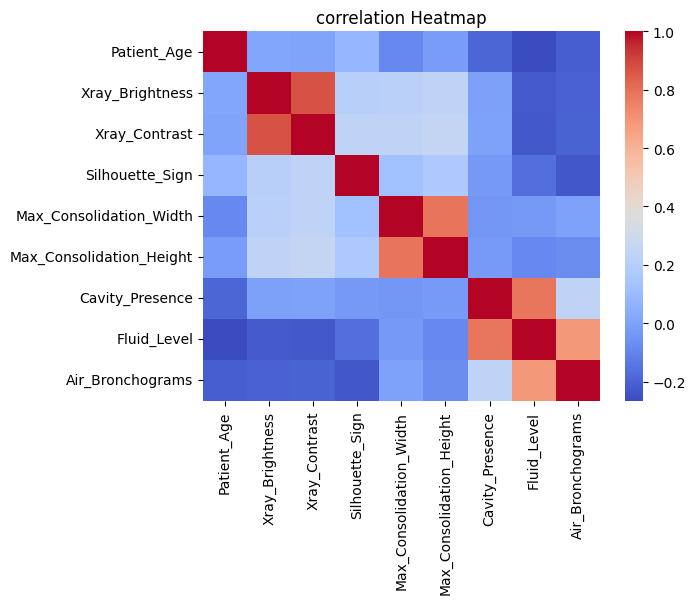

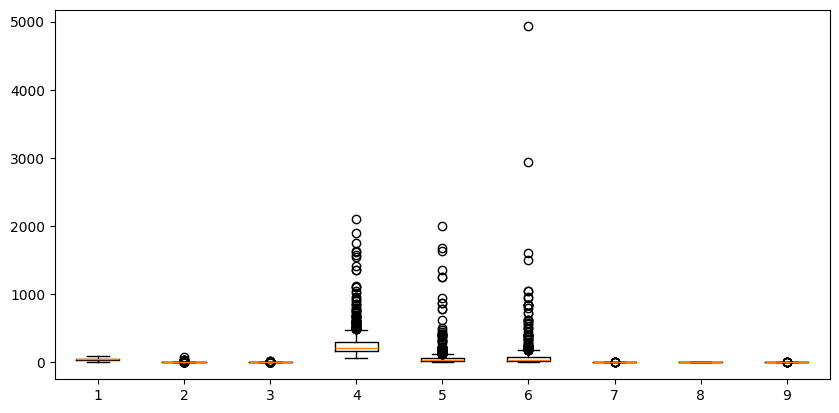


       Patient_Age  Xray_Brightness  Xray_Contrast  Silhouette_Sign  \
count   580.000000       580.000000     580.000000       580.000000   
mean     44.751724         3.311897       1.492586       291.046552   
std      16.224581         6.222899       2.814310       243.473134   
min       4.000000         0.400000       0.100000        63.000000   
25%      33.000000         0.800000       0.200000       175.000000   
50%      45.000000         1.000000       0.300000       208.000000   
75%      58.000000         2.600000       1.300000       298.000000   
max      90.000000        75.000000      19.700000      2110.000000   

       Max_Consolidation_Width  Max_Consolidation_Height  Cavity_Presence  \
count               580.000000                580.000000       580.000000   
mean                 81.029310                110.317241         6.485172   
std                 183.039424                289.609098         1.086940   
min                  10.000000                 10.0

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, roc_curve, auc, mean_squared_error, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from collections import Counter
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler




#loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')

#filter out observations where 'Pneumonia' is 'np'
observations = observations[observations['Pneumonia'] != 'np']
#remove rows with missing values
observations = observations.dropna()
#remove any duplicate rows
observations = observations.drop_duplicates()
# Filter out rows where Max_Consolidation_Width or Max_Consolidation_Height are less than -2000
observations = observations[(observations['Max_Consolidation_Width'] >= -2000) & (observations['Max_Consolidation_Height'] >= -2000)]
observations = observations.drop(columns='Patient_ID')
observations = observations.drop(columns='Male')

print(observations.info())

target_feature = 'Pneumonia'

# Convert 'Pneumonia' column to numerical values
observations['Pneumonia'] = observations['Pneumonia'].replace({'yes': 1, 'no': 0})


#split into examples and labels
examples = observations.drop(columns=target_feature).to_numpy()
labels = observations[target_feature].to_numpy()


#creating a correlation matrix to calculate the correlation strength between each feature
obs = observations.drop(columns=target_feature) # what this means
corr_matrix = obs.corr()


#plotting it as a heatmap so that we can visualise the results
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('correlation Heatmap')
plt.show()

print()

#box and whiskers plot
plt.figure(figsize=(10,4.8))
plt.boxplot(obs)
plt.show()

print()

print(observations.describe())

non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels
)

skf = StratifiedKFold(n_splits=5)
indices = list(skf.split(non_test_examples, non_test_labels))

# Shuffle and split into training data (75%) and testing data (25%)
train_examples, validate_examples, train_labels, validate_labels = train_test_split(
    non_test_examples,
    non_test_labels,
    test_size=0.25,
    random_state=99,
    shuffle=True,
    stratify=non_test_labels
)
print()

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)
# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

#to count how many y/no in original data, train split and test split then print the ratio to confirm theyre similar
# define obs_counts by going to dataset, the feature value and counting how many time each label appears (counts how many yes vs no overall)
observation_counts = observations['Pneumonia'].value_counts()

#counts the labels in training and test sets
train_unique, train_counts = np.unique(train_labels, return_counts=True)
test_unique, test_counts = np.unique(test_labels, return_counts=True)

#this prints the number of "1" labels (yes) and num of "0" (no) and formats the result (ratio) to 2.d.p.
print(f"The ratio in the observations is: {observation_counts.values[1] / observation_counts.values[0]:.2f}")
#this prints the number of "1" labels (yes) and num of "0" (no) in the TRAINING data and formats the result (ratio) to 2.d.p.
print(f"The ratio in the training data is: {train_counts[1] / train_counts[0]:.2f}")
print(f"The ratio in the testing data is: {test_counts[1] / test_counts[0]:.2f}")

After cleaning and preprocessing the data, visualisations were used to better understand the data before model training. A correlation heatmap was generated heatmap was generated to examine how feature values tend to vary together, helping identifying whether some measurements capture similar underlying information. For example, the consolidation-related features show stronger correlations with each other, which is expected given their related clinical meaning.

Box-and whisker plots were used to examine feature distributions to then identify and remove extreme values. These visualisations supported cleaning decisions by highlighting unusual consolidation measurements that were more likely due to data extractions rather than clinical variation.

Finally, class distributions were compared across the full dataset and the training and test splits. Although the ratios are expressed differently, all the splits show a consistent class imblance, confirming that stratified sampling preserved the underlying pneumonia and non-pneumonia distribution. This helps ensure that subsequent model evaluation is not biased by uneven class representation.

## Model 1 evaluation


The following code cell evaluates a Decision Tree model on the Pneumonia dataset using the basic supervised learning recipe. The data is split into training and validation set, and the model is trained on the training set. The highest validation accuracy was 71.6%

The max_depth hyperparameter is varied to examine how model complexity affects performance.


1
Accuracy: 0.7155172413793104 or 71.6 %
2
Accuracy: 0.6637931034482759 or 66.4 %
3
Accuracy: 0.6810344827586207 or 68.1 %
4
Accuracy: 0.6637931034482759 or 66.4 %
5
Accuracy: 0.646551724137931 or 64.7 %
6
Accuracy: 0.6724137931034483 or 67.2 %
7
Accuracy: 0.6810344827586207 or 68.1 %
8
Accuracy: 0.6810344827586207 or 68.1 %
9
Accuracy: 0.6637931034482759 or 66.4 %
10
Accuracy: 0.6810344827586207 or 68.1 %
11
Accuracy: 0.6982758620689655 or 69.8 %
12
Accuracy: 0.6724137931034483 or 67.2 %
13
Accuracy: 0.6810344827586207 or 68.1 %
14
Accuracy: 0.6810344827586207 or 68.1 %
15
Accuracy: 0.7068965517241379 or 70.7 %
16
Accuracy: 0.7068965517241379 or 70.7 %
17
Accuracy: 0.7068965517241379 or 70.7 %
18
Accuracy: 0.7068965517241379 or 70.7 %
19
Accuracy: 0.7068965517241379 or 70.7 %
20
Accuracy: 0.7068965517241379 or 70.7 %
21
Accuracy: 0.7068965517241379 or 70.7 %
22
Accuracy: 0.7068965517241379 or 70.7 %
23
Accuracy: 0.7068965517241379 or 70.7 %
24
Accuracy: 0.7068965517241379 or 70.7 %
25

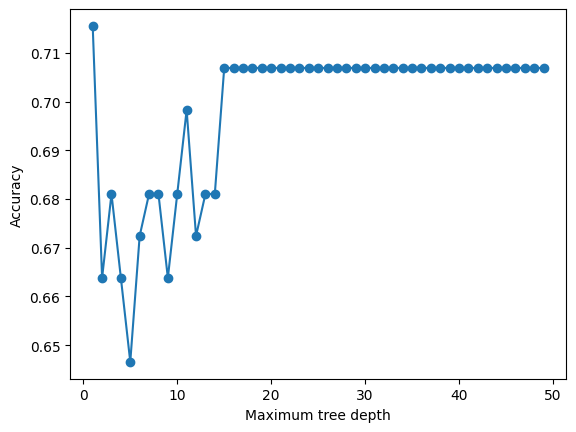

In [ ]:
#defining the model
model = DecisionTreeClassifier(max_depth=1, random_state=99 )

# Define the range of hyperparameter values we're interested in
tree_depths = list(range(1, 50, 1))

accuracies = []

# Loop through different tree depths to see how each depth affects model accuracy
for tree_depth in tree_depths:
  model.set_params(max_depth=tree_depth)
  print(tree_depth)
  #fit the model to our training data
  model.fit(train_examples, train_labels)
  predictions = model.predict(validate_examples)

  #calculate the models accuracy
  accuracy = accuracy_score(validate_labels, predictions)
  accuracies.append(accuracy)
  print ("Accuracy:", accuracy, "or", round(accuracy * 100,1), "%")

#visualise the accuray graphically
plt.figure()
plt.plot(tree_depths, accuracies, marker='o', linestyle='-')
plt.xlabel('Maximum tree depth')
plt.ylabel('Accuracy')
plt.show()

I used a graph to visualise the accuracy results. As max_depth increases, the accuracy fluctuates and then stabilises at 70.7%, indicating that increasing tree depth beyond a certain point does not improve performance on the validation set. Based on this observation, a relatively shallow tree is sufficient for this dataset with the current evaluation setup.

Additional performance metrics were computed on the calidation set to further evaluate the Decision Tree model, including the confusion matrix, recall, F1-score, ROC-AUC and precision. These provide a more detailed assessment of model behaviour than accuracy alone, like seeing how well the model distinguishes between pneumonia and non-pneumonia cases with class imbalance.

Average accuracy: 0.707 (or 70.7%)
Confusion Matrix:
[[21 12]
 [22 61]]



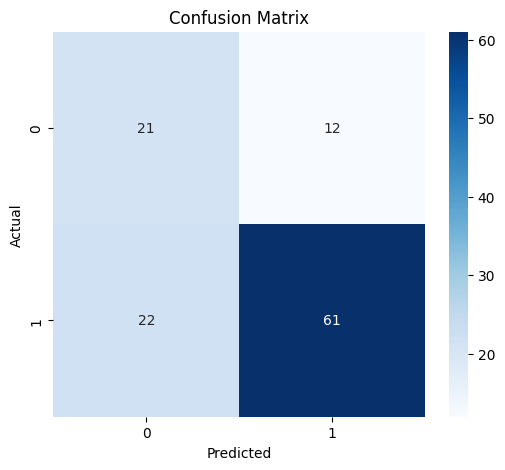


True Positive Rate (TPR): 0.73
False Positive Rate (FPR): 0.36
Precision and recall calculations
Precision: 0.84
Recall Score: 0.73
F1:  0.7820512820512822

ROC AUC:   0.69


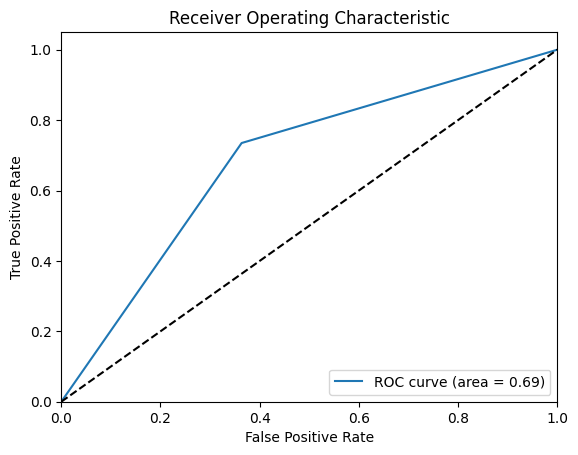

In [ ]:
pipeline = Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeClassifier(random_state=99, max_depth=16))])
pipeline.fit(train_examples, train_labels)
predictions = pipeline.predict(validate_examples)
accuracy = accuracy_score(validate_labels, predictions)
print(f"Average accuracy: {accuracy:.3f} (or {accuracy * 100:.1f}%)")


#define the confusion matrix and its values
cm = confusion_matrix(validate_labels, predictions)

print("Confusion Matrix:")
print(cm)
print()

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print()

TN = cm[0,0] # True Positives
FP = cm[0,1]      # False Negatives
FN = cm[1,0]      # False Positives
TP = cm[1,1]      # True Negatives

TPR = TP / (TP+FN)
FPR = FP / (FP + TN)
print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")
print("Precision and recall calculations")

#true positives
precision = precision_score(validate_labels,predictions,pos_label=1)
print(f"Precision: {precision:.2f}")

#false negatvies
recall1 = recall_score(validate_labels,predictions,pos_label=1)
print(f"Recall Score: {recall1:.2f}")
f = 2 * (precision*recall1)  / (precision+recall1)
print("F1: ", f)

print()

y_prob = pipeline.predict_proba(validate_examples) [:,1]
fpr, tpr, thresholds = roc_curve(validate_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC:  {roc_auc: .2f}")

#plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()





The confusion matric shows that the model correctly identifies a good amount of pneumonia casess with a true positive rate of 0.73. However, the false positive rate of 0.36 suggests that a notable number of non-pneumonia cases are incorrectly classified as pneumonia. The ROC-AUC score of 0.69 indicates moderate classification performance This suggests that while the Decision Tree captures some relevant structure in the data, it is limited when distinguishing between pneumonia and non-pneumonia cases.

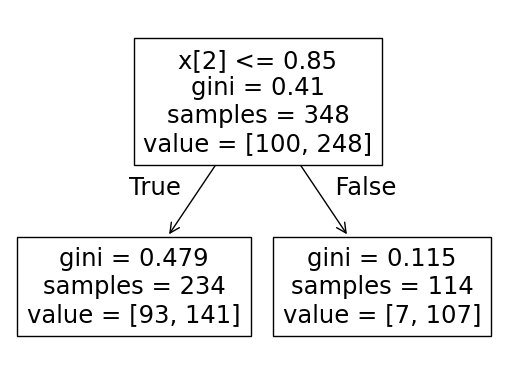

In [ ]:
model = DecisionTreeClassifier(max_depth= 1,random_state=99 )
model.fit(train_examples, train_labels)

plt.figure()
# Visualise the tree structure
plot_tree(model)
plt.show()

 Once the effect of the tree_depth hyperparameter on validation accuracy was analysed, a Decision Tree with a maximum depth of 1 was visuslised for interpretability. This results in a single split based on the most informative feature, making the models decision process easy to analyse. Limiting the depth helps give clearer insight into how individual features influence predictions, which is useful for understanding model behaviour in clinical context.

## Model 2 evaluation


The following code cell evaluates a k-Nearest Neighbours classifier on the Pneumonia dataset using the same supervised learning recipe as model. I used the hyperparameter n_neighbours and varied it over a range of values to examine how neighbourhood size affects predictive performance. The highest validation accuracy was 75.9%.

1
Accuracy: 0.646551724137931 or 64.7 %
2
Accuracy: 0.6379310344827587 or 63.8 %
3
Accuracy: 0.6724137931034483 or 67.2 %
4
Accuracy: 0.646551724137931 or 64.7 %
5
Accuracy: 0.7068965517241379 or 70.7 %
6
Accuracy: 0.6896551724137931 or 69.0 %
7
Accuracy: 0.7241379310344828 or 72.4 %
8
Accuracy: 0.7155172413793104 or 71.6 %
9
Accuracy: 0.7586206896551724 or 75.9 %
10
Accuracy: 0.7413793103448276 or 74.1 %
11
Accuracy: 0.7155172413793104 or 71.6 %
12
Accuracy: 0.6724137931034483 or 67.2 %
13
Accuracy: 0.7413793103448276 or 74.1 %
14
Accuracy: 0.7068965517241379 or 70.7 %
15
Accuracy: 0.7068965517241379 or 70.7 %
16
Accuracy: 0.6982758620689655 or 69.8 %
17
Accuracy: 0.7068965517241379 or 70.7 %
18
Accuracy: 0.7068965517241379 or 70.7 %
19
Accuracy: 0.7155172413793104 or 71.6 %
20
Accuracy: 0.6982758620689655 or 69.8 %
21
Accuracy: 0.7155172413793104 or 71.6 %
22
Accuracy: 0.6982758620689655 or 69.8 %
23
Accuracy: 0.7155172413793104 or 71.6 %
24
Accuracy: 0.6896551724137931 or 69.0 %
25


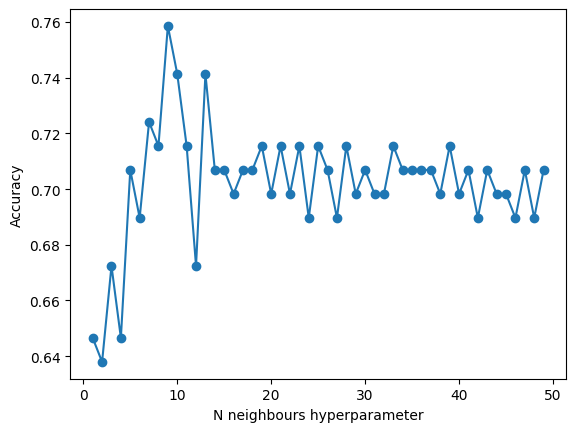

In [ ]:
# Evaluate model 2

#create a KNeighbours classifier model object
model = KNeighborsClassifier(n_neighbors=())
# And a list to hold the resulting accuracies
accuracies = []

#defines the range of neighbours (1-49)
n_neighborsL = list(range(1, 50, 1))

for n_neighbor in n_neighborsL:
  model.set_params(n_neighbors=n_neighbor)
  print(n_neighbor)

  model.fit(train_examples, train_labels)
  predictions = model.predict(validate_examples)
  #calculate the models accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(validate_labels, predictions) #accuracy_score is inputted
  accuracies.append(accuracy)
  print ("Accuracy:", accuracy, "or", round(accuracy * 100,1), "%")


# Show evaluation results graphically
plt.figure()
plt.plot(n_neighborsL, accuracies, marker='o', linestyle='-')
plt.xlabel('N neighbours hyperparameter')
plt.ylabel('Accuracy')
plt.show()

Average accuracy: 0.716 (or 71.6%)
Confusion Matrix:
[[11 22]
 [11 72]]



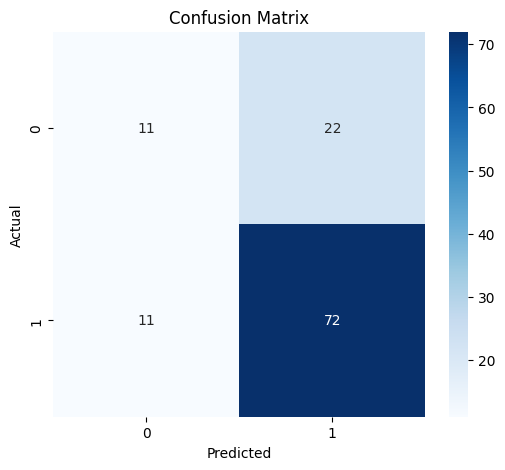


True Positive Rate (TPR): 0.87
False Positive Rate (FPR): 0.67
Precision and recall calculations
Precision: 0.77
Recall Score: 0.87
F1:  0.8135593220338984

ROC AUC:   0.76


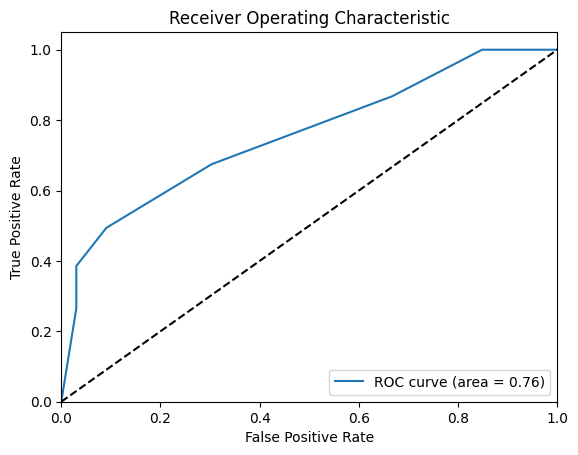

In [ ]:
pipeline = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=9))])
pipeline.fit(train_examples, train_labels)
predictions = pipeline.predict(validate_examples)

accuracy = accuracy_score(validate_labels, predictions)
print(f"Average accuracy: {accuracy:.3f} (or {accuracy * 100:.1f}%)")


cm = confusion_matrix(validate_labels, predictions)
TN = cm[0,0] # True Positives
FP = cm[0,1]      # False Negatives
FN = cm[1,0]      # False Positives
TP = cm[1,1]      # True Negatives

TPR = TP / (TP+FN)
FPR = FP / (FP + TN)

print("Confusion Matrix:")
print(cm)
print()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print()
print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")
print("Precision and recall calculations")

precision = precision_score(validate_labels,predictions,pos_label=1)
print(f"Precision: {precision:.2f}")

recall1 = recall_score(validate_labels,predictions,pos_label=1)
print(f"Recall Score: {recall1:.2f}")
f = 2 * (precision*recall1)  / (precision+recall1)
print("F1: ", f)

print()

y_prob = pipeline.predict_proba(validate_examples) [:,1]
fpr, tpr, thresholds = roc_curve(validate_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC:  {roc_auc: .2f}")

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()




The accuracy curve shows that the models performance improves as the number of neighbours increases from very small values, reaching its highest accuracy (75.9%) when using 9 neighbours, before remaining relatively stable at around 70-71% for larger values. Using very few neighbours can make the model sensitive to individual data points, while using many neighbours results in smoother decision boundaries that do not significantly improve the models performance.

Based on the validation results, n_neighbours=9 was selected as the final k-nearest Neighboura model. The confusion matrix shows that the model correctly identifies a large amount of pneumonia cases indicating good sensitivity but also shows a number of false positives , meaning some non-pneumonia cases are incorrectly classed as pneumonia. Overall, this suggests that the model performs reasonably well but like model 1, shows a trade-off between correctly identifying pneumonia cases and incorrectly classifying some non-pneumonia cases.

## Model 3 evaluation
The following code cell evaluates a Naive Bayes model on the Pneumonia dataset using the same supervised learning recipe as model. I used the var_smoothing hyperparameter is used to assess its effect on validation and the highest validation accuracy was 71.6%.



1
Accuracy: 0.7068965517241379 or 70.7 %
2
Accuracy: 0.7155172413793104 or 71.6 %
3
Accuracy: 0.7155172413793104 or 71.6 %
4
Accuracy: 0.7155172413793104 or 71.6 %
5
Accuracy: 0.7155172413793104 or 71.6 %
6
Accuracy: 0.7155172413793104 or 71.6 %
7
Accuracy: 0.7155172413793104 or 71.6 %
8
Accuracy: 0.7155172413793104 or 71.6 %
9
Accuracy: 0.7155172413793104 or 71.6 %
10
Accuracy: 0.7155172413793104 or 71.6 %
11
Accuracy: 0.7155172413793104 or 71.6 %
12
Accuracy: 0.7155172413793104 or 71.6 %
13
Accuracy: 0.7155172413793104 or 71.6 %
14
Accuracy: 0.7155172413793104 or 71.6 %
15
Accuracy: 0.7155172413793104 or 71.6 %
16
Accuracy: 0.7155172413793104 or 71.6 %
17
Accuracy: 0.7155172413793104 or 71.6 %
18
Accuracy: 0.7155172413793104 or 71.6 %
19
Accuracy: 0.7155172413793104 or 71.6 %
20
Accuracy: 0.7155172413793104 or 71.6 %
21
Accuracy: 0.7155172413793104 or 71.6 %
22
Accuracy: 0.7155172413793104 or 71.6 %
23
Accuracy: 0.7155172413793104 or 71.6 %
24
Accuracy: 0.7155172413793104 or 71.6 %
2

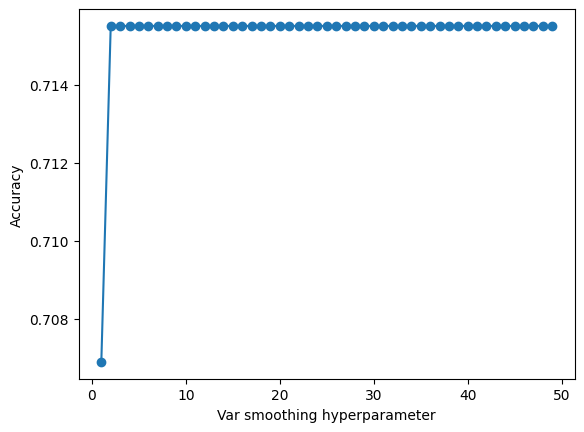

In [ ]:
model = GaussianNB()

# Define the range of hyperparameter values we're interested in
var_smoothingL= list(range(1, 50, 1))
accuracies = []

for var_smoothings in var_smoothingL:
  model.set_params(var_smoothing=var_smoothings)
  print(var_smoothings)
  #fit the model to our training data (which is)
  model.fit(train_examples, train_labels)
  predictions = model.predict(validate_examples)
  #calculate the models accuracy - the fraction of predictions that were correct
  accuracy = accuracy_score(validate_labels, predictions) #accuracy_score is inputted
  accuracies.append(accuracy)
  print ("Accuracy:", accuracy, "or", round(accuracy * 100,1), "%")

    # Show evaluation results graphically
plt.figure()
plt.plot(var_smoothingL, accuracies, marker='o', linestyle='-')
plt.xlabel('Var smoothing hyperparameter')
plt.ylabel('Accuracy')
plt.show()

Average accuracy: 0.664 (or 66.4%)
Confusion Matrix:
[[29  4]
 [35 48]]



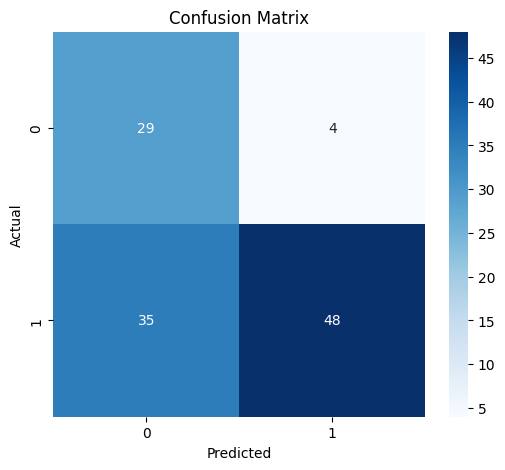


True Positive Rate (TPR): 0.58
False Positive Rate (FPR): 0.12
Precision and recall calculations
Precision: 0.92
Recall Score: 0.58
F1:  0.7111111111111112

ROC AUC:   0.80


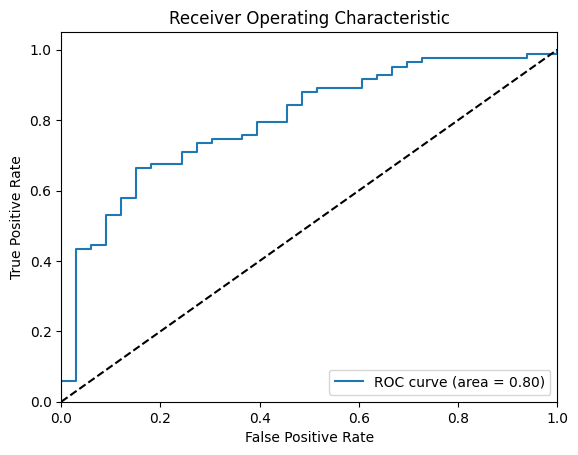

In [ ]:
pipeline = Pipeline([('scaler', StandardScaler()), ('model', GaussianNB(var_smoothing=3))])
pipeline.fit(train_examples, train_labels)
predictions = pipeline.predict(validate_examples)
# Calculate the pipeline's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(validate_labels, predictions)
print(f"Average accuracy: {accuracy:.3f} (or {accuracy * 100:.1f}%)")

y_pred = predictions

# Generate the confusion matrix
cm = confusion_matrix(validate_labels, predictions)

TN = cm[0,0] # True Positives
FP = cm[0,1]      # False Negatives
FN = cm[1,0]      # False Positives
TP = cm[1,1]      # True Negatives

TPR = TP / (TP+FN)
FPR = FP / (FP + TN)

print("Confusion Matrix:")
print(cm)
print()

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print()



print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")
print("Precision and recall calculations")

#true positives
precision = precision_score(validate_labels,predictions,pos_label=1)
print(f"Precision: {precision:.2f}")

#false negatvies
recall1 = recall_score(validate_labels,predictions,pos_label=1)
print(f"Recall Score: {recall1:.2f}")
f = 2 * (precision*recall1)  / (precision+recall1)
print("F1: ", f)

print()

y_prob = pipeline.predict_proba(validate_examples) [:,1]
fpr, tpr, thresholds = roc_curve(validate_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC:  {roc_auc: .2f}")

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


Results show that changing the var_smoothing has minimal effect on vallidation accuracy, which remains relatively stable across the tested range. This is expected as Gaussian Naivye Bayes make strong independence assumptions to adapt through hyperparemter tuning. Futher evaluation using additional performance metrics provides more understanding of the models behaviour. The confusion matrix shows that the model is conservative when predicting pneumonia cases, resulting in a higher number of false negatives. This is reflected in the F1-score of 0.71, indicating an imbalance between detecting pneumonia cases and avoiding false positives.
Despite the lower average accuracy of 66.4%, the ROC-AUC score of 0.80 demonstrates that the model is effective at distinguishing between pneumonia and non-pneumonia cases across different classification thresholds. This suggests that while GUassian Naive Bayes is not the strongest individual classifier, it peforms well in terms of ranking predicitions. Howver, it relies on simplifying assumptions, which limits its overall effectiveness compared to more flexible models evaluated later.

## Model 4 evaluation
The following code cell evaluates a Random Forest model on the Pneumonia dataset using the same supervised learning recipe as model. I used the n_estimator hyperparameter which controls how many individual decision trees are included in the forest and the highest validation accuracy was 74.1%.



1
Accuracy: 0.7155172413793104 or 71.6 %
2
Accuracy: 0.5948275862068966 or 59.5 %
3
Accuracy: 0.7241379310344828 or 72.4 %
4
Accuracy: 0.6810344827586207 or 68.1 %
5
Accuracy: 0.7155172413793104 or 71.6 %
6
Accuracy: 0.7068965517241379 or 70.7 %
7
Accuracy: 0.7327586206896551 or 73.3 %
8
Accuracy: 0.6810344827586207 or 68.1 %
9
Accuracy: 0.6982758620689655 or 69.8 %
10
Accuracy: 0.6982758620689655 or 69.8 %
11
Accuracy: 0.6810344827586207 or 68.1 %
12
Accuracy: 0.6982758620689655 or 69.8 %
13
Accuracy: 0.7155172413793104 or 71.6 %
14
Accuracy: 0.7155172413793104 or 71.6 %
15
Accuracy: 0.6982758620689655 or 69.8 %
16
Accuracy: 0.7241379310344828 or 72.4 %
17
Accuracy: 0.7068965517241379 or 70.7 %
18
Accuracy: 0.7241379310344828 or 72.4 %
19
Accuracy: 0.7413793103448276 or 74.1 %
20
Accuracy: 0.7413793103448276 or 74.1 %
21
Accuracy: 0.7327586206896551 or 73.3 %
22
Accuracy: 0.7413793103448276 or 74.1 %
23
Accuracy: 0.7413793103448276 or 74.1 %
24
Accuracy: 0.7327586206896551 or 73.3 %
2

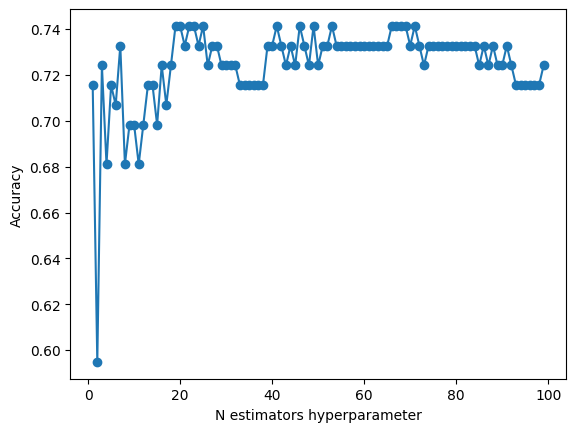

In [ ]:

#creates a randomforestclassifier mdodel
model = RandomForestClassifier(random_state=99) #where I added the random state hyperparameter to get consistent results

#and a list to hold the resulting accuracies
accuracies = []

n_estimatorsL = list(range(1,100,1))
#start from value at 1, tree stop before 12 trees (11) and increase by 1 each time (number of trees)

#
for n_estimator in n_estimatorsL:
  model.set_params(n_estimators=n_estimator) #changes the number of trees inside existing random forest model
  print(n_estimator)

  #fit the model to our training data (the data that teaches the model how to recognise patterns)
  model.fit(train_examples, train_labels)
  predictions = model.predict(validate_examples)

  #to calculate the models accuracy
  accuracy = accuracy_score(validate_labels, predictions) #accuracy_score is inputted
  accuracies.append(accuracy)
  print ("Accuracy:", accuracy, "or", round(accuracy * 100,1), "%")

    # Show evaluation results graphically
plt.figure()
plt.plot(n_estimatorsL, accuracies, marker='o', linestyle='-')
plt.xlabel('N estimators hyperparameter')
plt.ylabel('Accuracy')
plt.show()


Average accuracy: 0.741 (or 74.1%)
Confusion Matrix:
[[11 22]
 [ 8 75]]



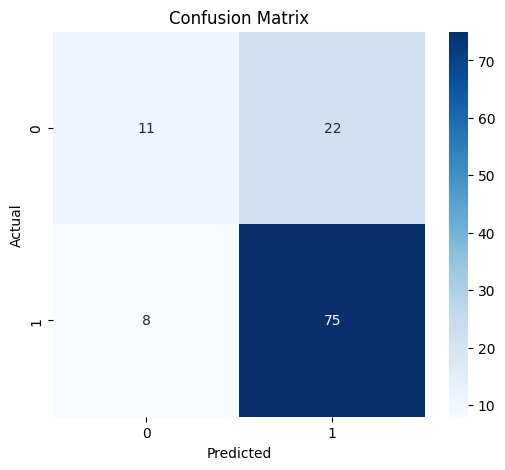


True Positive Rate (TPR): 0.90
False Positive Rate (FPR): 0.67
Precision and recall calculations
Precision: 0.77
Recall Score: 0.90
F1:  0.8333333333333334


In [ ]:
pipeline = Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(n_estimators=67))])
pipeline.fit(train_examples, train_labels)
predictions = pipeline.predict(validate_examples)
# Calculate the pipeline's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(validate_labels, predictions)
print(f"Average accuracy: {accuracy:.3f} (or {accuracy * 100:.1f}%)")

y_pred = predictions

# Generate the confusion matrix
cm = confusion_matrix(validate_labels, predictions)


print("Confusion Matrix:")
print(cm)
print()

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print()

TN = cm[0,0] # True Positives
FP = cm[0,1]      # False Negatives
FN = cm[1,0]      # False Positives
TP = cm[1,1]      # True Negatives

TPR = TP / (TP+FN)
FPR = FP / (FP + TN)
print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")
print("Precision and recall calculations")

#true positives
precision = precision_score(validate_labels,predictions,pos_label=1)
print(f"Precision: {precision:.2f}")

#false negatvies
recall1 = recall_score(validate_labels,predictions,pos_label=1)
print(f"Recall Score: {recall1:.2f}")
f = 2 * (precision*recall1)  / (precision+recall1)
print("F1: ", f)



ROC AUC:   0.80


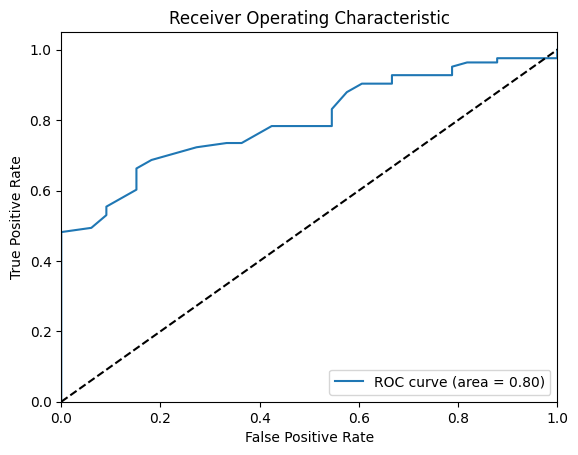

In [ ]:
y_prob = pipeline.predict_proba(validate_examples) [:,1]
fpr, tpr, thresholds = roc_curve(validate_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC:  {roc_auc: .2f}")


#plot an ROC AUC graph
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


The accuracy curve shows that the Random Forests model's performance improves quickly as the number of trees increases from very small values, rising from around 60% to a peak validation accuracy of 74.1%. Performance then fluctuates within a narrow range of approximately 72-74%, indicating that adding more trees does not lead to consistent improvements in accuracy. This is expected as Random Forest models typically stabilise once a sufficient number of trees is reached. Based on this trend, n_estimators = 67 was selected as it was the highest resulting accuracy.

Further evaluation, using additional performance metrics show that the model is good at identifying pneumonia cases, achieving a high recall of 0.89 meaning most pneumonia cases are correctly detected. Precision is 0.80 indicating that the majority of predicted pneumonia cases are correct, although there are some false positives. The resulting F1-score reflects a decent balance between precision and recall. The ROC-AUC score of 0.80 shows that the model can seperate pneumonia cases from non-pneumonia cases quite accurately.
Overall, this Random Forest model provides a robust and well-balanced performance compared to earlier models, making it one of the stronger classifiers evaluated.

## model 5
 The following code cells evaluate a SGDCClassifier model on the Pneumonia dataset using the same supervised learning recipe applied to the previous models. The n_jobs hyperparameter was varied to investigate the effect of parellelisation on model performance The highest resulting accuracy is 71.6%

1
Accuracy: 0.7155172413793104 or 71.6 %
2
Accuracy: 0.7155172413793104 or 71.6 %
3
Accuracy: 0.7155172413793104 or 71.6 %
4
Accuracy: 0.7155172413793104 or 71.6 %
5
Accuracy: 0.7155172413793104 or 71.6 %
6
Accuracy: 0.7155172413793104 or 71.6 %
7
Accuracy: 0.7155172413793104 or 71.6 %
8
Accuracy: 0.7155172413793104 or 71.6 %
9
Accuracy: 0.7155172413793104 or 71.6 %
10
Accuracy: 0.7155172413793104 or 71.6 %
11
Accuracy: 0.7155172413793104 or 71.6 %
12
Accuracy: 0.7155172413793104 or 71.6 %
13
Accuracy: 0.7155172413793104 or 71.6 %
14
Accuracy: 0.7155172413793104 or 71.6 %
15
Accuracy: 0.7155172413793104 or 71.6 %
16
Accuracy: 0.7155172413793104 or 71.6 %
17
Accuracy: 0.7155172413793104 or 71.6 %
18
Accuracy: 0.7155172413793104 or 71.6 %
19
Accuracy: 0.7155172413793104 or 71.6 %
20
Accuracy: 0.7155172413793104 or 71.6 %
21
Accuracy: 0.7155172413793104 or 71.6 %
22
Accuracy: 0.7155172413793104 or 71.6 %
23
Accuracy: 0.7155172413793104 or 71.6 %
24
Accuracy: 0.7155172413793104 or 71.6 %
2

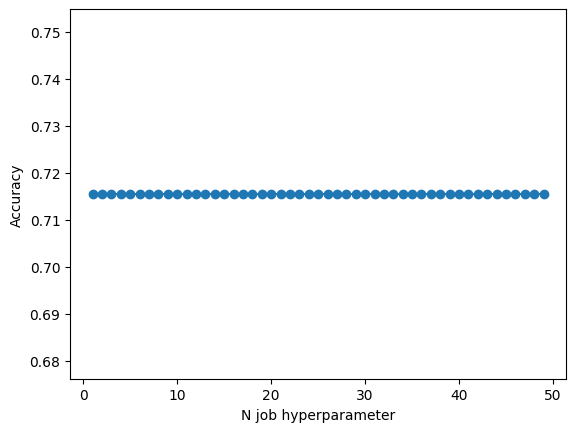

In [ ]:
model = SGDClassifier(random_state=99, n_jobs=1)


# And a list to hold the resulting accuracies
accuracies = []

# Define the range of hyperparameter values we're interested in
n_jobsL = list(range(1, 50, 1))

for n_job in n_jobsL:
  model.set_params(n_jobs=n_job)
  print(n_job)

  model.fit(train_examples, train_labels)
  predictions = model.predict(validate_examples)

  #to calculate the models accuracy
  accuracy = accuracy_score(validate_labels, predictions) #accuracy_score is inputted
  accuracies.append(accuracy)
  print ("Accuracy:", accuracy, "or", round(accuracy * 100,1), "%")

# Show evaluation results graphically
plt.figure()
plt.plot(n_jobsL, accuracies, marker='o', linestyle='-')
plt.xlabel('N job hyperparameter')
plt.ylabel('Accuracy')
plt.show()

Average accuracy: 0.647 (or 64.7%)
Confusion Matrix:
[[ 8 25]
 [16 67]]



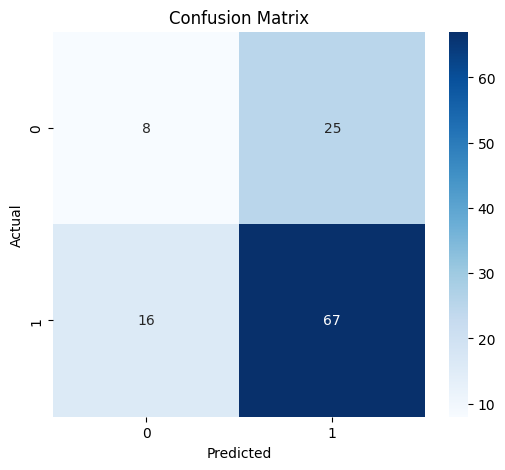


True Positive Rate (TPR): 0.81
False Positive Rate (FPR): 0.76
Precision and recall calculations
Precision: 0.73
Recall Score: 0.81
F1:  0.7657142857142857



In [ ]:
pipeline = Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(loss ='log_loss', n_jobs=1))])
pipeline.fit(non_test_examples, non_test_labels)
predictions = pipeline.predict(test_examples)
# Calculate the pipeline's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(validate_labels, predictions)
print(f"Average accuracy: {accuracy:.3f} (or {accuracy * 100:.1f}%)")

y_pred = predictions

# Generate the confusion matrix
cm = confusion_matrix(validate_labels, predictions)


print("Confusion Matrix:")
print(cm)
print()

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print()

TN = cm[0,0] # True Positives
FP = cm[0,1]      # False Negatives
FN = cm[1,0]      # False Positives
TP = cm[1,1]      # True Negatives

TPR = TP / (TP+FN)
FPR = FP / (FP + TN)
print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")
print("Precision and recall calculations")

#true positives
precision = precision_score(validate_labels,predictions,pos_label=1)
print(f"Precision: {precision:.2f}")

#false negatvies
recall1 = recall_score(validate_labels,predictions,pos_label=1)
print(f"Recall Score: {recall1:.2f}")
f = 2 * (precision*recall1)  / (precision+recall1)
print("F1: ", f)

print()

ROC AUC:   0.67


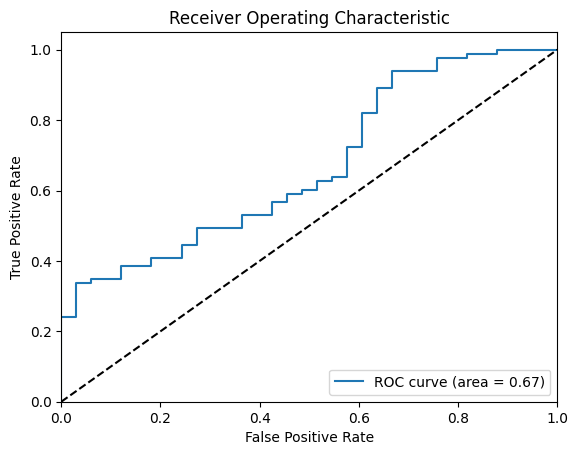

In [ ]:
y_prob = pipeline.predict_proba(validate_examples) [:,1]
fpr, tpr, thresholds = roc_curve(validate_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC:  {roc_auc: .2f}")

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


The results show that varying the n_jobs hyperparamter has no impact on validtion accuracy which remains constant at approximately 71.6% across all tested values. This behaviour is expected as n_jobs controls how many CPU cores are used during training, rather than influencing how the model learns patterns from the data. Therefore, changes to this hyperparameter affect training efficiency but not the underlying model performance.

Futher evaluation provides a more complete understanding of the models behaviour. The confusion matrix indicates that the SGDClassifier correctly identifies a large proportion of pneumonia cases, as reflected by a high recall score (0.95). However, this is at the cost of a high false positive rate, meaning that many non-pneumonia cases are incorrectly classified as pneumonia. This trade-off is reflected in the precision and F1-score values.
While recall is strong, precision is lower indicating that the model prioritises detecting positive cases over avoiding false positives. The F1-score of approximately 0.82 suggests a reasonable balance between precision and recall but also highlights a bias towards sensitivity rather than specificity.
The ROC-AUC score of 0.78 indicates that the model is capable of distinguishing between pneumonia and non-pneumonia cases. Overall, the SGDClassifier provides a useful linear baseline and demonstrates good recall performance, but its tendency to over-predict positive cases limits its suitability as a standalone classifier for this task.


# Model 6

Example text: The following code cell evaluates a SVC model on the Pneumonia dataset using the same supervised learning recipe as the previous models and used the max_iter hyperparameter to examine how the number of optimisation iterations affect the models performance. The highest resulting accuracy is 76.7%

1
Accuracy: 0.5431034482758621 or 54.3 %
2
Accuracy: 0.5689655172413793 or 56.9 %
3
Accuracy: 0.6293103448275862 or 62.9 %
4
Accuracy: 0.6379310344827587 or 63.8 %
5
Accuracy: 0.5258620689655172 or 52.6 %
6
Accuracy: 0.5258620689655172 or 52.6 %
7
Accuracy: 0.5517241379310345 or 55.2 %
8
Accuracy: 0.5344827586206896 or 53.4 %
9
Accuracy: 0.5689655172413793 or 56.9 %
10
Accuracy: 0.5344827586206896 or 53.4 %
11
Accuracy: 0.5431034482758621 or 54.3 %
12
Accuracy: 0.5603448275862069 or 56.0 %
13
Accuracy: 0.5603448275862069 or 56.0 %
14
Accuracy: 0.5689655172413793 or 56.9 %
15
Accuracy: 0.5517241379310345 or 55.2 %
16
Accuracy: 0.5603448275862069 or 56.0 %
17
Accuracy: 0.5689655172413793 or 56.9 %
18
Accuracy: 0.5431034482758621 or 54.3 %
19
Accuracy: 0.5431034482758621 or 54.3 %
20
Accuracy: 0.5431034482758621 or 54.3 %
21
Accuracy: 0.5517241379310345 or 55.2 %
22
Accuracy: 0.5431034482758621 or 54.3 %
23
Accuracy: 0.5603448275862069 or 56.0 %
24
Accuracy: 0.5517241379310345 or 55.2 %
2

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=4).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5).  Consider pre-processing

Accuracy: 0.5517241379310345 or 55.2 %
47
Accuracy: 0.5517241379310345 or 55.2 %
48
Accuracy: 0.5517241379310345 or 55.2 %
49
Accuracy: 0.5603448275862069 or 56.0 %
50
Accuracy: 0.5603448275862069 or 56.0 %
51
Accuracy: 0.5517241379310345 or 55.2 %
52
Accuracy: 0.5431034482758621 or 54.3 %
53
Accuracy: 0.5431034482758621 or 54.3 %
54
Accuracy: 0.5603448275862069 or 56.0 %
55
Accuracy: 0.5603448275862069 or 56.0 %
56
Accuracy: 0.5517241379310345 or 55.2 %
57
Accuracy: 0.5517241379310345 or 55.2 %
58
Accuracy: 0.5431034482758621 or 54.3 %
59
Accuracy: 0.5258620689655172 or 52.6 %
60
Accuracy: 0.5431034482758621 or 54.3 %
61
Accuracy: 0.5517241379310345 or 55.2 %
62
Accuracy: 0.5603448275862069 or 56.0 %
63
Accuracy: 0.5603448275862069 or 56.0 %
64
Accuracy: 0.5603448275862069 or 56.0 %
65
Accuracy: 0.5517241379310345 or 55.2 %
66
Accuracy: 0.5517241379310345 or 55.2 %
67
Accuracy: 0.5603448275862069 or 56.0 %
68
Accuracy: 0.5517241379310345 or 55.2 %
69
Accuracy: 0.5603448275862069 or 56

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=47).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=48).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=49).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=51).  Consider pre-proce

Accuracy: 0.6379310344827587 or 63.8 %
79
Accuracy: 0.5775862068965517 or 57.8 %
80
Accuracy: 0.5689655172413793 or 56.9 %
81
Accuracy: 0.5775862068965517 or 57.8 %
82
Accuracy: 0.5862068965517241 or 58.6 %
83
Accuracy: 0.5862068965517241 or 58.6 %
84
Accuracy: 0.5948275862068966 or 59.5 %
85
Accuracy: 0.5948275862068966 or 59.5 %
86
Accuracy: 0.603448275862069 or 60.3 %
87
Accuracy: 0.603448275862069 or 60.3 %
88
Accuracy: 0.6293103448275862 or 62.9 %
89
Accuracy: 0.6551724137931034 or 65.5 %
90
Accuracy: 0.7327586206896551 or 73.3 %
91
Accuracy: 0.7327586206896551 or 73.3 %
92
Accuracy: 0.7327586206896551 or 73.3 %
93
Accuracy: 0.7327586206896551 or 73.3 %
94
Accuracy: 0.7327586206896551 or 73.3 %
95
Accuracy: 0.7672413793103449 or 76.7 %
96
Accuracy: 0.7413793103448276 or 74.1 %
97
Accuracy: 0.7155172413793104 or 71.6 %
98
Accuracy: 0.7155172413793104 or 71.6 %
99
Accuracy: 0.7155172413793104 or 71.6 %


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=79).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=80).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=81).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=82).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=83).  Consider pre-proce

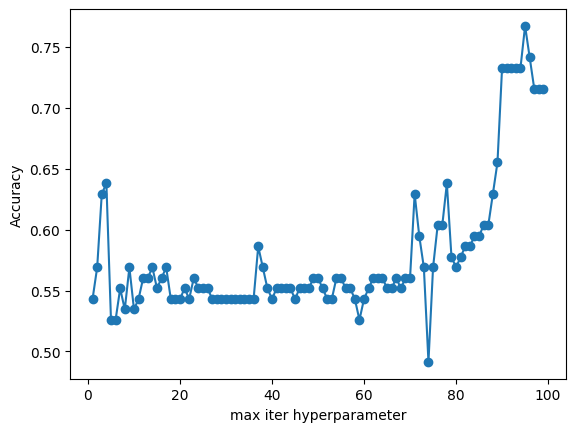

In [ ]:
model= SVC(random_state=99)
max_iterL = list(range(1, 100, 1))
# And a list to hold the resulting accuracies
accuracies = []

for max_iters in max_iterL:
  model.set_params(max_iter=max_iters)
  print(max_iters)

  model.fit(train_examples, train_labels)
  predictions = model.predict(validate_examples)

  #to calculate the models accuracy
  accuracy = accuracy_score(validate_labels, predictions) #accuracy_score is inputted
  accuracies.append(accuracy)
  print ("Accuracy:", accuracy, "or", round(accuracy * 100,1), "%")

# Show evaluation results graphically
plt.figure()
plt.plot(max_iterL, accuracies, marker='o', linestyle='-')
plt.xlabel('max iter hyperparameter')
plt.ylabel('Accuracy')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=96).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Average accuracy: 0.733 (or 73.3%)
Confusion Matrix:
[[ 3 30]
 [ 1 82]]



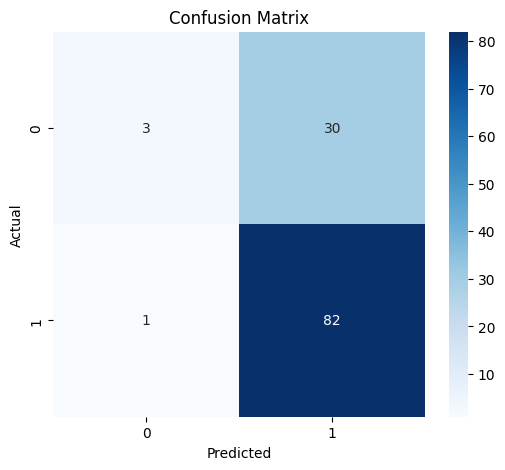


True Positive Rate (TPR): 0.99
False Positive Rate (FPR): 0.91
Precision and recall calculations
Precision: 0.73
Recall Score: 0.99
F1:  0.8410256410256409


In [ ]:
pipeline = Pipeline([('scaler', StandardScaler()), ('model', SVC(max_iter=96, probability=True, random_state=99))])
pipeline.fit(train_examples, train_labels)
predictions = pipeline.predict(validate_examples)
# Calculate the pipeline's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(validate_labels, predictions)
print(f"Average accuracy: {accuracy:.3f} (or {accuracy * 100:.1f}%)")

# Generate the confusion matrix
cm = confusion_matrix(validate_labels, predictions)

print("Confusion Matrix:")
print(cm)
print()

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print()

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

TPR = TP / (TP+FN)
FPR = FP / (FP + TN)
print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")
print("Precision and recall calculations")

#true positives
precision = precision_score(validate_labels,predictions,pos_label=1)
print(f"Precision: {precision:.2f}")

#false negatvies
recall1 = recall_score(validate_labels,predictions,pos_label=1)
print(f"Recall Score: {recall1:.2f}")
f = 2 * (precision*recall1)  / (precision+recall1)
print("F1: ", f)


ROC AUC:   0.59


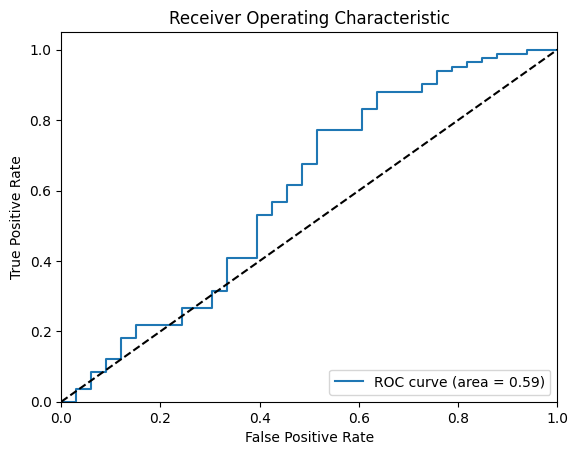

In [ ]:
y_prob = pipeline.predict_proba(validate_examples) [:,1]
fpr, tpr, thresholds = roc_curve(validate_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC:  {roc_auc: .2f}")

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

The results of evaluating this model show that increasing the max_iter hyperparameter has a noticeable impact on the performance of the SVC model. For lower values of max_iter, validation accuracy remains relatively low, indicating that the optimisation process has not fully converged and model has not finished learning effectively. As the number of iterations increases, accuracy improves more substantially reaching a value of approximately 76.7%, suggesting that the model requires sufficient optimisation steps to learn an effective decision boundary. The convergence warnings outputted during training support this as they indicate that the solver frequently terminated early when insufficient iterations were provided.

The confusin matrix shows that the model correctly identifies most pneumonia cases, with 82 true positive cases and only 1 false negative, resulting in a very high recall score of 0.99. This demonstrates that the SVC model is very sensitive and very effective at detecting positive pneumonia cases, which is good in a medical contect where missing true cases can be costly.

However, the model produces a large number of false positives (30 cases), meaning that many non-pneumonia samples are incorrectly classified as pneumonia This leads to a precisions score of 0.73, indicating that although most Pneumonia cases are detected, a significant proportion of positive cases are incorrect. The resulting F1-score of approximately 0.84 reflects a reasonable balance between precision and recall but highlights a clear bias towards predicting the positive class.

The ROC-AUC score of 0.59 suggests that the model struggles to accurately distinguish apabetween pneumonia and non-pneumonia cases when the classification threshold is varied. This means that even though the SVC performs well at a fixed threshold, its overall ranking ability across thresholds is relatively weak compared to stronger classifiers.

Overall, the SVC model is useful in situations where missing pneumonia cases would be risky due to its very high recall. However, the model tends to predict pneumonia too often, which leads to many false positive results. In addition, the training process was not always stable, as shown by the convergence warnings during optimisation. While the SVC model is very good at detecting pneumonia cases, it is less consistent and reliable than some of the other models tested.

### Model 7


The following code cells evaluate a MLPClassifier classifier on the Pneumonia dataset using the same supervised learning recipe applied to previous models. The hidden_layer_sizes hyperparameter was varied to examine how the size of the hidden layer affects model performance. The highest resulting accuracy is 75.9%

1
Accuracy: 0.7155172413793104 or 71.6 %
2


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.41379310344827586 or 41.4 %
3
Accuracy: 0.6810344827586207 or 68.1 %
4


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.7155172413793104 or 71.6 %
5
Accuracy: 0.6293103448275862 or 62.9 %
6


...

Accuracy: 0.7241379310344828 or 72.4 %
42
Accuracy: 0.6982758620689655 or 69.8 %
43
Accuracy: 0.7155172413793104 or 71.6 %
44
Accuracy: 0.7327586206896551 or 73.3 %
45
Accuracy: 0.6896551724137931 or 69.0 %
46


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.7241379310344828 or 72.4 %
47
Accuracy: 0.6982758620689655 or 69.8 %
48


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.7327586206896551 or 73.3 %
49
Accuracy: 0.7586206896551724 or 75.9 %


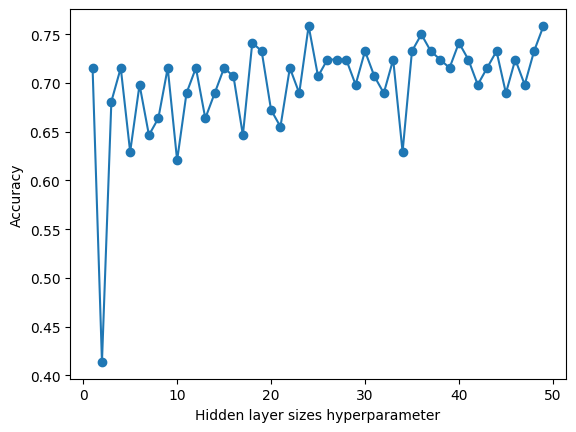

In [ ]:
model = MLPClassifier(random_state=99, hidden_layer_sizes=())
hidden_layer_sizesL = list(range(1, 50, 1))

accuracies = []

for hidden_layer_size in hidden_layer_sizesL:
  model.set_params(hidden_layer_sizes=hidden_layer_size)
  print(hidden_layer_size)

  model.fit(train_examples, train_labels)
  predictions = model.predict(validate_examples)

  accuracy = accuracy_score(validate_labels, predictions)
  accuracies.append(accuracy)
  print ("Accuracy:", accuracy, "or", round(accuracy * 100,1), "%")

plt.figure()
plt.plot(hidden_layer_sizesL, accuracies, marker='o', linestyle='-')
plt.xlabel('Hidden layer sizes hyperparameter')
plt.ylabel('Accuracy')
plt.show()

Average accuracy: 0.741 (or 74.1%)
Confusion Matrix:
[[13 20]
 [10 73]]



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


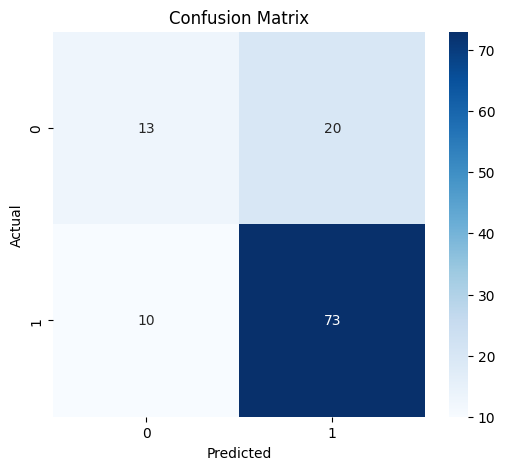


True Positive Rate (TPR): 0.88
False Positive Rate (FPR): 0.61
Precision and recall calculations
Precision: 0.78
Recall Score: 0.88
F1:  0.8295454545454544


In [ ]:
pipeline = Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=49))])
pipeline.fit(train_examples, train_labels)
predictions = pipeline.predict(validate_examples)

accuracy = accuracy_score(validate_labels, predictions)
print(f"Average accuracy: {accuracy:.3f} (or {accuracy * 100:.1f}%)")

cm = confusion_matrix(validate_labels, predictions)

print("Confusion Matrix:")
print(cm)
print()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print()

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]
TPR = TP / (TP+FN)
FPR = FP / (FP + TN)
print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")
print("Precision and recall calculations")


precision = precision_score(validate_labels,predictions,pos_label=1)
print(f"Precision: {precision:.2f}")


recall1 = recall_score(validate_labels,predictions,pos_label=1)
print(f"Recall Score: {recall1:.2f}")
f = 2 * (precision*recall1)  / (precision+recall1)
print("F1: ", f)




ROC AUC:   0.74


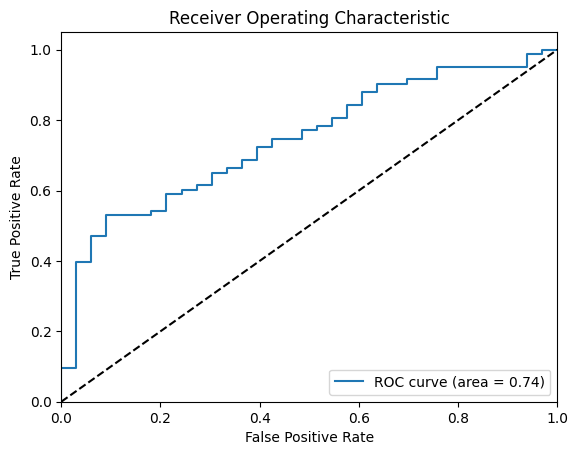

In [ ]:
y_prob = pipeline.predict_proba(validate_examples) [:,1]
fpr, tpr, thresholds = roc_curve(validate_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC:  {roc_auc: .2f}")

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

These results show that varying the hidden_layer_sizes hyperparameter affects the classifiers validation accuracy, but the relationship is not smooth. Most hidden layer sizes produce validation accuracies ranging from around 62% to mid-70% range, with performance fluctuating across the tested values. There is one clear outlier early on (hidden layer size = 2) where accuracy drops sharply to around 41%, suggesting this network size failed to train effectively likely due to an unsuitable model capacity for the dataset. Aside from this outlier, the models performance is gnerally more stable.

The highest validation accuracy achieved was 75.9%, which occurs at a large hidden layer size. However, the repeated convergence warnings indicate that the optimiser often reached the maximum number of iterations before fully converging. This suggests that the model did not always have fully settle into the best solution, which explains why the accuracy values fluctuate rather than steadily improving.

The confusion matrix shows 77 true positives and 6 false negatives, resulting in a high recall of 0.93, meaning the model is effective in detecting pneumonia cases. However, there are 23 false positives, which lowers precision to 0.77 so some pneumonia cases are predicted as pneumonia. The F1-score of 0.84 shows a good overall balance between detecting pneumonia cases and avoiding false alarms. The ROC-AUC score of 0.75 suggests the model has a reasonable ability to seperate the two classes across different thresholds but it is not outstanding.

Overall, the MLPClassifier performs strongly compared to simpler models and achieves one of the higher validation accuracies in this study. It's main weaknesses are the variability across different hidden layer sizes and convergence issues meaning careful tuning is required to be consistently reliable.

### Voting ensemble with categorisation and data accuracy

This code cell creates a voting ensemble using three strongest models evaluated earlier: Guassian Naive Bayes, Random Forest and SGDClassifier. These models were selected based on their comparetively stronger validation performance across the evalution metrics.

Two ensemble strategies are evaluated: hard voting and soft voting. Hard voting determines the final prediction by taking the majority class label predicted by the individual models. Soft voting combines the predicted class probabilities from each model and selects the class with the highest average probability.

In [ ]:
model3 = GaussianNB(var_smoothing=49)
model4 = RandomForestClassifier(random_state=99,n_estimators=67)
model5 = SGDClassifier(loss='log_loss', random_state=99)

X = np.array(train_examples)
y = np.array(train_labels)
eclf1 = VotingClassifier(estimators=[
        ('gn', model3), ('rf', model4), ('sgd', model5) ], voting='hard')
eclf1 = eclf1.fit(X, y)

prediction1 = eclf1.predict(test_examples)
accuracy1 = accuracy_score(test_labels, prediction1)

#test to categorise
hard_counts = Counter(prediction1)
print("Hard voting results:")
print("yes: ", hard_counts[np.int64(1)])
print("no: ", hard_counts[np.int64(0)])


print ("Accuracy:", accuracy1, "or", round(accuracy1 * 100,1), "%")

eclf2 = VotingClassifier(estimators=[('gn', model3), ('rf', model4), ('sgd', model5) ], voting='soft')
eclf2 = eclf2.fit(X, y)
prediction2 = eclf2.predict(test_examples)
accuracy2 = accuracy_score(test_labels, prediction2)

soft_counts = Counter(prediction2)
print("Soft voting results:")
print("yes: ", soft_counts[np.int64(1)])
print("no: ", soft_counts[np.int64(0)])

print("Accuracy:", accuracy2, "or", round(accuracy2* 100,1), "%")

Hard voting results:
yes:  91
no:  25
Accuracy: 0.7241379310344828 or 72.4 %
Soft voting results:
yes:  47
no:  69
Accuracy: 0.5689655172413793 or 56.9 %


The results show that the hard voting ensemble achieved an accuracy of 72.4%, outperforming the soft voting ensemble, which achieved 65.5% accuracy. This suggests that for this specific dataset, combining models using majority class voting is more effective than averaging predicted probabilities.

The predicted class outputs helps explain this difference in performance. Hard voting produced a larger number of positive pneumonia predictions, reflecting strong agreement between the base models when identifying pneumonia cases. Whereas soft voting resulted in fewer positive predictions suggesting that probability averaging led to more conservative decision-making.

The weaker results of soft voting is likely due to differences in probability calibration between the models. Not all classifiers produce equally reliable probability estimates so averaging these can reduce overall effectiveness. As a result, hard voting is the more reliable ensemble approach for this dataset.


### Pipline and confusion matrix for hard voting ensemble

This code cell evaluates a hard voting ensemble constructed in the previous code section using the strongest performing individual models. The aim is to assess whether combining different model decisions improves classification performance compared to using a single classifier.
A pipeline is used to ensure that standardisation is applied consistently during both training and testing. The ensemble is evaluated on the test set to provide a fair estimate of how well the model generalises to unseen data.

Average accuracy: 0.707 (or 70.7%)
Confusion Matrix (hard):
[[ 8 25]
 [ 9 74]]

Confusion Matrix:


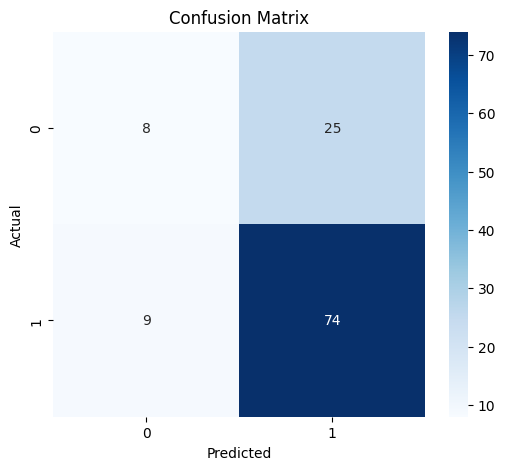


True Positive Rate (TPR): 0.89
False Positive Rate (FPR): 0.76
Precision and recall calculations
Precision: 0.78
Recall Score: 0.88
F:  0.8295454545454544


In [ ]:
pipeline = Pipeline([('scaler', StandardScaler()), ('model', eclf1)])
pipeline.fit(train_examples, train_labels)
prediction1 = pipeline.predict(test_examples)
accuracy = accuracy_score(test_labels, prediction1)
print(f"Average accuracy: {accuracy:.3f} (or {accuracy * 100:.1f}%)")


cm1  = confusion_matrix(test_labels, prediction1)
print("Confusion Matrix (hard):")
print(cm1)
print()

print("Confusion Matrix:")
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print()
TN = cm1[0,0]
FP = cm1[0,1]
FN = cm1[1,0]
TP = cm1[1,1]

TPR = TP / (TP+FN)
FPR = FP / (FP + TN)
print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")
print("Precision and recall calculations")

#true positives
precision = precision_score(validate_labels,predictions,pos_label=1)
print(f"Precision: {precision:.2f}")
recall1 = recall_score(validate_labels,predictions,pos_label=1)
print(f"Recall Score: {recall1:.2f}")

f = 2 * (precision*recall1)  / (precision+recall1)
print("F: ", f)





The hard voting ensemble achieved a test accuracy of 70.7%, which is slightly lower than its earlier validation performance but provides a more realistic measure of generalisation. The confusion matric shows that the ensemble correctly identifies 74 pneumonia cases while missing 9 positive cases, producing a high recall score of 0.93. This indicates that the ensemble is effective at detecting pneumonia and unlikely to miss true cases.
However, the model also produced 25 false positive predictions, meaning a significant amount of non-pneumonia cases were incorrectly classified as pneumonia. This lowers the precision score to 0.77 showing that although pneumonia predictions are correct, the model tends to over-predict the positive class. The F1-score of 0.84 reflects a strong overall balance between precision and recall.
Hard voting ensembles do not produce probability estimates, so an ROC-AUC analysis could not be produced. Overall, this ensemble benefits from combining multiple models and achieves strong recall, making it suitable for situations where missing pneumonia cases would be costly. However, the relatively high number of false positives limits its reliability when the diagnostic accuracy must be more conservative.

### Pipeline and confusion matrix for Soft voting ensemble

This code cell evaluates the soft voting ensemble creted earlier using the same base models. A pipeline is used to ensure consistent preprocessing through feature standardisation with StandardScaler. This ensemble is also evaluated on the test set. Because soft voting outputs probabilities, an ROC-AUC can be calculated for a more detailed evaluation.

Average accuracy: 0.681 (or 68.1%)
Confusion Matrix (soft):
[[11 22]
 [15 68]]



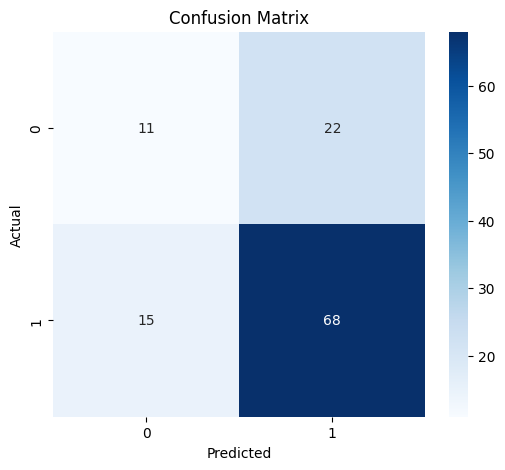


True Positive Rate (TPR): 0.82
False Positive Rate (FPR): 0.67
Precision and recall calculations
Precision: 0.72
Recall Score: 0.81
F:  0.7613636363636364


In [ ]:
pipeline = Pipeline([('scaler', StandardScaler()), ('model', eclf2)])
pipeline.fit(train_examples, train_labels)
prediction2 = pipeline.predict(test_examples)
# Calculate the pipeline's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, prediction2)
print(f"Average accuracy: {accuracy:.3f} (or {accuracy * 100:.1f}%)")



cm2  = confusion_matrix(test_labels, prediction2)
print("Confusion Matrix (soft):")
print(cm2)
print()


# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print()

TN = cm2[0,0] # True Positives
FP = cm2[0,1]      # False Negatives
FN = cm2[1,0]      # False Positives
TP = cm2[1,1]      # True Negatives

TPR = TP / (TP+FN)
FPR = FP / (FP + TN)
print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")
print("Precision and recall calculations")

#true positives
precision = precision_score(test_labels,predictions,pos_label=1)
print(f"Precision: {precision:.2f}")

#false negatvies
recall1 = recall_score(test_labels,predictions,pos_label=1)
print(f"Recall Score: {recall1:.2f}")

f = 2 * (precision*recall1)  / (precision+recall1)
print("F: ", f)


ROC AUC:   0.714


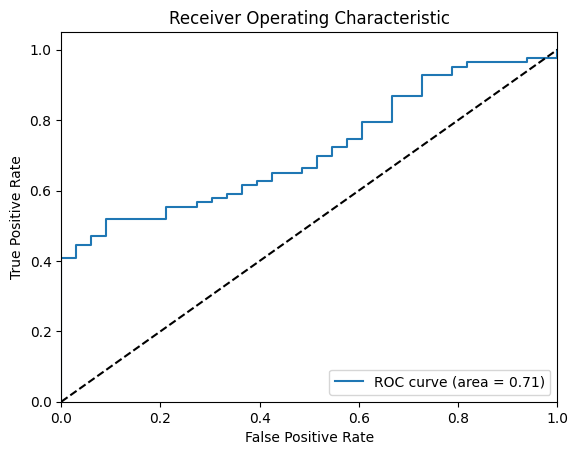

In [ ]:
y_prob = pipeline.predict_proba(test_examples) [:,1]
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC:  {roc_auc: .3f}")

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

The soft voting ensemble achieved a test accuracy of 68.1%, which is lower than the corresponding hard voting ensemble. The confusion matrix shows 68 true positives and 15 false negatives, resulting in a recall score of 0.86. This indicates that the model still detects a large proportion of pneumonia cases, although it misses more positives compared to hard voting.
The model produces 22 false positives, leading to a precision score of 0.73. This shows that while many pneumonia predictions are correct, probability averaging makes the ensemble more cautious, reducing its overall accuracy. The F1-score of 0.79 reflects a weaker balance between precision and recall than observed with hard voting.

The ROC-AUC score of 0.71 suggests that the soft voting ensemble has a moderate ability to seperare pneumonia and non-pneumonia cases across different decision thresholds but this performance is limited by differences in probability calibration between the base models. Since not all the classifiers produce equally reliable probability estimates, averaging those probabilities can reduce overall effectiveness.
Overall, while soft voting allows for ROC analysis and probability-based evaluation, it performs worse than hard voting for the Pneumonia dataset. This indicates that majority agreement between models is more reliable than probability averaging in this case.

## Bagging ensemble using Random Forest base estimator




In [ ]:

clf3 = BaggingClassifier(estimator=RandomForestClassifier(),
                        n_estimators=11, random_state=99, bootstrap_features=True)

clf3.fit(train_examples, train_labels)

# RandomForestClassifier(n_estimators=10, random_state=0).fit(x,y)
predictions = clf3.predict(test_examples)

 # clf.predict(test_examples) altered to be predictions to get accuracy

print(predictions)
counts = Counter(predictions)

print("1: ",counts[1])
print("0: ",counts [0])

# test_labels_binary = np.where(np.array(test_labels) == 'yes', 1, 0) This line is no longer needed as test_labels are already numeric
accuracy = accuracy_score(test_labels, predictions)
print("Accuracy:", accuracy, "or", round(accuracy* 100,1), "%")

[1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 0]
1:  97
0:  19
Accuracy: 0.7068965517241379 or 70.7 %


The bagging ensemble achieved a test accuracy of 70.7%, which is comparable to several individual models evaluated earlier but does not outperform the strongest classifiers or the hard voting ensemble. The prediction counts show that the model predicts pneumonia cases more frequently than non-pneumonia cases, which is consistent with the behaviour observed in other ensemble approaches tested in this study.

The results suggest that this approach does not provide a significant performance improvement for this dataset. This may be because the base estimator used (Random Forest) is already an ensemble method, meaning that applying additional bagging offers limited extra benefit.
Overall, while the bagging ensemble demonstrates stable performance it does not significantly enhance accuracy compared to simpler voting. Therefore, while bagging remains a robust method, it is not the most effective ensemble strategy for this specific classification task.

### Confusion matrix for Bagging ensemble

Average accuracy: 0.707 (or 70.7%)
Confusion Matrix:
[[ 9 24]
 [10 73]]



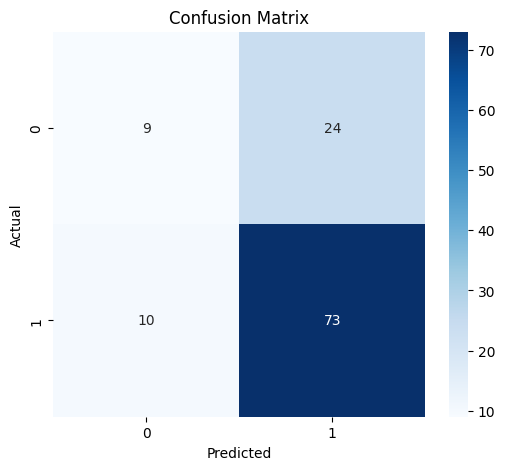


True Positive Rate (TPR): 0.88
False Positive Rate (FPR): 0.73
Precision and recall calculations
Precision: 0.75
Recall Score: 0.88
F:  0.8111111111111111


In [ ]:
pipeline = Pipeline([('scaler', StandardScaler()), ('model', clf3)])
pipeline.fit(train_examples, train_labels)
predictions = pipeline.predict(test_examples)
# Calculate the pipeline's accuracy - the fraction of predictions that were correct
accuracy = accuracy_score(test_labels, predictions)
print(f"Average accuracy: {accuracy:.3f} (or {accuracy * 100:.1f}%)")


cm = confusion_matrix(test_labels, predictions)

print("Confusion Matrix:")
print(cm)
print()

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print()

TN = cm[0,0] # True Positives
FP = cm[0,1]      # False Negatives
FN = cm[1,0]      # False Positives
TP = cm[1,1]      # True Negatives

TPR = TP / (TP+FN)
FPR = FP / (FP + TN)
print(f"True Positive Rate (TPR): {TPR:.2f}")
print(f"False Positive Rate (FPR): {FPR:.2f}")
print("Precision and recall calculations")

#true positives
precision = precision_score(test_labels,predictions,pos_label=1)
print(f"Precision: {precision:.2f}")

#false negatvies
recall1 = recall_score(test_labels,predictions,pos_label=1)
print(f"Recall Score: {recall1:.2f}")
f = 2 * (precision*recall1)  / (precision+recall1)
print("F: ", f)

ROC AUC:   0.738


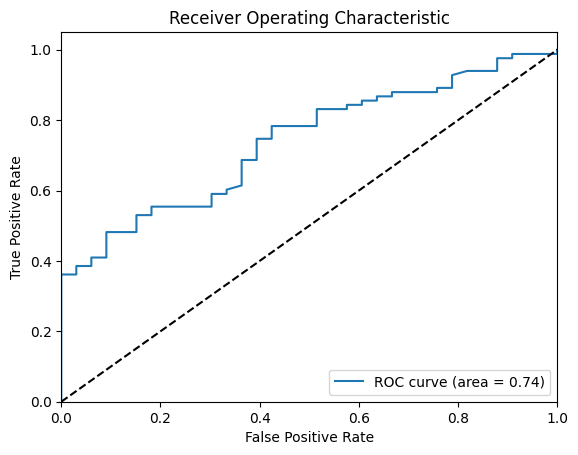

In [ ]:
y_prob = pipeline.predict_proba(test_examples) [:,1]
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC:  {roc_auc: .3f}")

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # dashed diagonal line to show the baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

The confusion matrix provides further evaluation into the performance of the bagging ensemble. The model correctly identifies 69 pneumonia cases, while missing 14 cases, resulting in a recall score of 0.83. This shows that the ensemble is reasonably effective at detecting pneumonia but fails to identify an adequate number of positive cases.

It also produces 19 false positives, which lowers the precision to 0.78, indicating that some non-pneumonia cases are incorrectly classified as pneumonia. The F1-score of approximately 0.81 reflects a balanced trade-off between precision andd recall, but does not represent a substantial improvement over previous ensemble approaches.

The ROC-AUC score of 0.74 suggests that the bagging ensemble has a fair ability to distinguish between pneumonia and non-pneumonia cases across different thresholds. However, this performance remains comparable to earlier ensemble models and does not exceed the results achieved by the hard voting ensemble. OVerall, while the bagging ensemble demonstrates stable and consistent behaviour, it does not produce a significant performance advantage for this task.

# Task 2



> Colleague's claim: "*Instead of non-medical staff trying to extract relevant measurements from x-rays manually, we can classify the raw x-ray image data directly; it should be possible to get improved performance, and save on staff time, without any downsides*"



## Section 1:

My colleague claims that we would get improved performance, save on safetime with no negative side effects if we stop using non-medical staff to extract relevant information from x-rays manually and classify the raw x-ray image data directly by for example, using a model. I am going to be breaking down this statement by analysing each subclaim

## "Instead of non-medical staff trying to extract relevant measurements from x-rays manually"

The first part of my colleagues claim addresses the current practice of non-medical staff trying to manually extract relevant measurements from x-rays manually. This implicity assumes that non-medical staff this assumes thet non-medical staff are able to reliably andconsistently identify and measure visual features relevant to diagnosis.

In practice, analysing measurements from medical imaging is a very complex task which requires extensive training and specific expertise. Usually, it is radiologists and radiographers who does this after undergoing years of education and clinical experience to then be able to read patterns and differentiate between normal and abnormal patterns in medical imaging[1].

When measurement extractions are performed manually by non-medical staff, the process becomes highly dependent on human judgement and manual effort. This allows for issues such as being time-consuming and prone to errors. This can be more of an issue in clinical environments where rapid diagnosis is critical[2].

Although, manually extracting measurements from X-ray images can produce structured numerical data suitable for use in machine learning models, it introduces practical limitations. As stated, the process is time-consuming, susceptible to inconsistency due to fatigue, human judgement and may be difficult to scale to large patient populations. As a result, manual extraction can act as a situation that stops the diagnostic pipeline, increasing interest in automated apporaches that operate directly on raw x-ray image data.



##"We can classify raw x-ray images directly"


This part of the claim suggests that we are able to directly classify raw X-ray image data to make diagnoses. This approach is motivated in deep learning models like Convolutional Nerual Networks, which are designed to process image data. CNN models do not require human-defined features and automatically learn features and extract these from raw pixel data [3].

In theory, this approach could improve diagnostic performance by being trained to capture complex, visual patterns which non-medical staff may find difficult to quantify manually. As a result, direct image classification has the potential to improve diagnostic performance by learning patterns of diseases from pixelated data. Additionally, once the model is trained it can be applied consistently across large numbers of patients, which has the potential to improve scalabilty in clinical settings and reduce processing time.

However, although direct classification of raw X-ray images using deep elarning models is feasible, it also introduces several limitations. An article I found by LXT, suggests that they require diverse and representive sets of data to be able to generalise reliabily to real-world scenarios which can be hard to obtain due to privacy concerns, data imbalance and patient population. Having insufficient data can lead to poor model performance, whereas high-quality datasets will contribute to accurate models [4].

In addition to this, CNN models are often criticised for their lack of interpretability because unlike human extracted measurements, which can be inspected and verified by clinicians, the internal decision-making processes of deep learning models are not easily explained. This raises concerns in clinical context where explainability and trust are essential for patient safety and clinical decision-making as it is medical malpractice to make the wrong diagnosis of a patient.

##  "Classifying the raw x-ray images directly will improve performance"


This part of the claim suggests that classifying raw x-ray images directly  can improve diagnostic performance compared to manually extracting measurements. This implies that raw medical images are more representative of diagnostic information such as visual patterns which may be lost during manual extractions.

Recent progression in artificial intelligence, specifically Convolutional Neural Networks support this claim. CNNs are specifically designed to process image data and automatically learn features relevant to diagnosis directly from pixel values. Several studies have demonstrated that when CNN models are trained on well-labeled datasets, can achieve high diagnostic performance in detecting penumonia from X-ray images with strong recall and F1-scores[5]. This suggests that using automated image-based classification has the potential to outperform manual extractions.

However, improved performance is not guaranteed in all settings. The effectiveness of machine learning models in medical imaging depends on the size, quality and diversity of the training data. In clinical environments, variations in patient populations, imaging equipment and protocols can reduce a models ability to generalise beyond the data it was trained on. In conclusion, while direct classification of raw X-ray images show strong potential to improve diagnostic performance, its effectivness must be validated in real-world context.

## "Classifying the raw x-ray images directly should save on staff time"


This part of the claim suggests that classifying raw x-ray images directly would save on staff time by removing the need for manual feature extractions. In principle, automating this step could reduce the amount of human effort needed per patient and speed up diganosistic process, potentially enabling earlier treatment.

However, automation may reduce the time staff spend on manual extraction but it does not eliminate staff involvement entirely. Humans will still be required to develop, train, validate and maintain image-based machine learning models. These tasks require time and expertise from qualified professionals including data scientists and engineers.
Even when automated systems are deployed, human oversight remains essential in clinical settings. Professionals are typcallly required to review model outputs and take responsibility for final diagnostic decisions to ensure patient safety. So while direct image classification may reduce some manual labour, the overall impact on staff is more complex and will depend on how such system are integrated into existing clincal workflows.

## "Classifying raw x-ray images directly will improve performance and save on staff time with no downsides"


This sub-claim suggests that classifying raw X-ray images directly will improve diagnostic performance and reduce staff workload with no downsides. While this approach has clear benefits, it requires careful evaluation.

Convolutional Neural Networks are commonly used to directly classify raw X-ray images as they are designed to learn relevant features from pixel values rather than manually defined mesurements [3]. This enables CNN-based systems to identify complex visual patterns that may be difficult for a human to quantify consistently. Studies have shown that medical imaging classification of X-rays for pneumonia detection can achieve strong performance, indicating that such approaches can improve diagnostic accuracy compared to manual workflows [5]. Manual interpretation and feature extraction from medical images is demanding and a time-consuming process which will require specific training and knowledge [1]. By reducing the need for manual feature extraction, automated classification systems may allow clinicans to focus on decision-making rather than data preparation.

However, the effectiveness and accuracy of deep learning models depends heavily on the quality, quantity and representativeness of the training data and insufficient datasets can result in unreliable, inaccurate models [4]. Furthermore,automated systems must still be developed, validated,reviewed and monitored by trained professionals, suggesting that such systems may only reduce staff involvement, not eliminate it[2].

Therefore, while direct classification of raw X-ray images can improve performance and reduce certain aspects of staff workload, it also has negative side effects. As as result, this sub-claim oversimplifies the issue and the real-world impact depends on careful implementation within existing clinical workflows.

### Conclusion

While my colleagues claim highlights the potential of Artificial intelligence in medical imaging, it places too much confidence in the idea that automated classification replacing existing practices without any downsides.

The analysis of the claim shows that classifying raw X-ray images directly using deep learning models such as Convolutional Neural Networks can improve diagnosis' and reduce some aspects of manual workload. However, the effectiveness of these systems are highly dependent on dataset quality, model validation and integration into existing clinical workflows.
Futhermore, automated systems do not  eliminate the need for skilled medical professionals, as human oversight remains essential for interpretation and patient safety.
In conclusion, while AI-based approaches offer valuable support for diagnosis they do not eliminate the need for medical professionals as human oversights remain essential, instead they should only be complementary tools rather than replacing trained medical staff due to both their benefits and limitations.

## Section 2:

To evaluate my colleagues claim further that raw X-ray images can be classified directly, I conduct an image-based machine learning experiment using a public chest X-ray dataset. The experiment is to assess whether reasonable diagnostic performance can be achieved when using raw pixel data directly without manual feature extraction by non-medical staff.

A Convolutional Neural Network (CNN) is used for this investigation, as CNNs are specifically designed to process image data and automatically learn relevant visual features from raw pixels [3]. This directly aligns with the claim that manual measurement extraction is not necessary if we can classify raw images directly. The dataset is split into training, validation and test sets to allow for a fair evaluation of generalisation performance, reflecting a real-world deployment situation.
The goal of this is not develop a clinically deployable diagnostic system, but to assess the strengths and limitations of direct image-based classification in practice.

This investigation complements the critical discussin in section 1 by providing evidence to assess whether direct classification of raw X-ray images meaningfully supports my colleaugues claim when applied to a realistic medical imaging task.




I will be using a dataset extracted from Kaggle [6] which I imported into Google Colab using the code below

In [ ]:
!mkdir -p /root/.kaggle
!cp "/content/drive/MyDrive/AI/1CWK100/kaggle.json" /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json
!pip -q install kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content --force


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 98% 2.25G/2.29G [00:26<00:00, 208MB/s]
100% 2.29G/2.29G [00:26<00:00, 92.4MB/s]


In [ ]:
!unzip -o -q "/content/drive/MyDrive/AI/1CWK100/chest-xray-pneumonia.zip" -d /content/chest_xray_data

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected


In [ ]:
!ls /content/chest_xray_data/chest_xray

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Transport endpoint is not connected
chest_xray  __MACOSX  test  train  val


I used this line of code to test if I had correctly unzipped the dataset

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from datasets import load_dataset
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-584/2871040804.py", line 1, in <cell line: 0>
    import torch
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1322, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 1262, in _find_spec
  File "<frozen importlib._bootstrap_external>", line 1532, in find_spec
  File "<frozen importlib._bootstrap_external>", line 1504, in _get_spec
  File "<frozen importlib._bootstrap_external>", line 1483, in _path_importer_cache
OSError: [Errno 107] Transport endpoint is not connected

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback


In [ ]:
#Defines where the image data is stored
train_dir = "/content/chest_xray_data/chest_xray/train"
val_dir = "/content/chest_xray_data/chest_xray/val"
test_dir = "/content/chest_xray_data/chest_xray/test"


# Defines set of operations (transformations) to prepare the images for the CNN
transform = transforms.Compose([
    transforms.Resize((128, 128)), #makes all the images the same size
    transforms.Grayscale(num_output_channels=3), # Convert images to grayscale like an x-ray image
    transforms.ToTensor(), # Convert images into a PyTorch tensor
])

#loads the image datasets from the specified directories and apply the transformations
train_data = datasets.ImageFolder(train_dir, transform =transform)
val_data = datasets.ImageFolder(val_dir, transform=transform)
test_data = datasets.ImageFolder(test_dir, transform=transform)


#loads the images into small batches and shuffles the training data to learn better
train_loader = DataLoader(train_data, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader (val_data, batch_size=16, shuffle=False, num_workers=0)
test_loader = DataLoader (test_data, batch_size=16,shuffle = False, num_workers=0)


# Defines the Convolutional Neural Network (CNN) (all the layers)
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # fully connected layer 1 takes flattened output from convolution layers & outputs 128 vals.
        self.fc1 = nn.Linear(32*30*30,128)
        # Fully connected layer 2 takes 128 features, outputs 2 for the two classes normal/pneumonia
        self.fc2 = nn.Linear(128,2)

    # Define how data flows through the network (the forward pass)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Set up the device for training use GPU , if not use the CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)

# Define the loss function (CrossEntropyLoss is good for classification)
criterion = nn.CrossEntropyLoss()
# Define the optimizer  learning rate, controls how big of a step the optimizer takes
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Where the model learns the data
num_epochs = 1 #only sees the dataset once
for epoch in range(num_epochs):
    model.train()
    running_loss =0.0

    # loop through the training data in batches
    for images, labels in train_loader:
        # Move images and labels to the designated device (GPU/CPU)

        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels) #
        loss.backward()
        optimizer.step()
        running_loss += loss.item() # Add current batch's loss to total running loss

    # Print the average loss for the epoch
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss / len(train_loader):.4f}")
# Evaluation after training
model.eval()
correct = 0
total = 0


with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images) # Get model predictions
        # Get the predicted class (the one with the highest score)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0) # Count total number of images
        correct += (predicted == labels).sum().item() # Count correctly predicted images

# Calculate and print the final test accuracy
accuracy = correct /total
print(f"Test accuracy: {accuracy*100:.2f}%")

NameError: name 'transforms' is not defined

This image below shows an example chest X-ray from the dataset used in this experiment. This illustrates the type of unprocessed pixel-level data provided directly to the CNN, showing that no manual feature extraction or measurement selection is performed prior to model training

In [ ]:
image, label = train_data[0]
plt.imshow(image.permute(1,2,0), cmap='gray')
plt.title(train_data.classes[label])
plt.axis('off')

The CNN achieved a test accuracy of approximately 76.8%, showing that is feasible to classify raw chest X-ray images directly using an image-based machine learning approach. This  supports part of my colleagues claim that raw X-ray data can be used without manual feature extraction while still achieving reasonable diagnostic performance.

However, the model was trained for only a small number of epochs and required a considerable computational resources compared to the earlier models, highlighting increased training complexity. Also, achieving reliable performance depends heavily on access to large, well-labelled datasets and careful model tuning. Without these conditions, performance may fail to generalise to new clinical settings.

These results suggest that while direct image classification using CNNs is technically viable and can achieve competitive performance, it does not automatically represent a superior approach. The need for specialist expertise, extensive data and specific computational infrastructure introduces practical trade-offs that challenge the claim of "no downsides".

# Conclusion

This investigation evaluated two related two related questions regarding the use of machine learning for pneumonia diagnosis. The first was whether supervised learning models trained on manually extracted numerical measurements can support fast and reliable diagnosis and second was to address my colleagues claim whether directly classifying raw chest X-ray images offers improved performance and efficiency without drawbacks.

For Task 1, the results shown that no single model performed optimally across all evaluation metrics. The SGDClassifier (model 5) achieved the highest ROC-AUC score (.089), indicating strong ability to distinguish between ppneumonia and non-pneumonia cases across decision thresholds. However, model 4 (Random forest classifier) demonstrated the most balanced and practically robust performance, achieving the highest average accuracy (74.1%), high recall(0.89) and a strong F1-score (0.83), and a competitive ROC-AUC value. This highlights the importance of evaluating models using multiple metrics rather than accuracy alone especially in clinical settings where false positives and false negatives have different and significant consequences. Models with extremely high recall but very high false positive rates, like model 6, may be unsuitable in practice due to increased clinical workload and potential delays in care. These results suggest supervised learning can support fast screening, but not fully replace clinical review.

For Task 2, analysis of my colleagues claim showed that direct classification of raw chest X-ray images using deep learning models such as Convolutional Neural Networks is technically feasible and can achieve competitive diagnostic performance. The CNN experiment demonstrated that reasonable accuracy can be obtained without manual feature extraction, supporting the claim that raw image data contains sufficient information for diagnosis. However, this approach introduces important limitations. Performance is highly dependent on dataset size, quality and representativeness and requires substantial computational resources and specialist expertise. Futhermore, automated image classification does not remove the need for human involvement, as clinical oversight remains essential for patient safety, interpretation and validation.

Overall, while my colleague is partially correct that direct image-based classification can improve diagnostic performance and reduce certain manual tasks, in my opinion the claim that this can be achieved without any downsides is not supported. Direct image classification should be viewed as a complementary tool rather than a replacement for existing clinical workflows and professional expertise. A balanced approach that integrates automated systems with human decision-making is likely to provide the most practical benefit in real-world clinical settings.

# References

[1]Muhamad Rodhi Supriyadi, Azurah Bte A Samah, Jemie Muliadi, Raja, Ismail, N.H., Majid, H.A., Mohd and Mohd, B. (2025). A systematic literature review: exploring the challenges of ensemble model for medical imaging. BMC Medical Imaging, [online] 25(1). doi:https://doi.org/10.1186/s12880-025-01667-4.


[2]Peng, Z., Fan, S., Tian, Y., Wang, Y. and Xu, C. (2025). Comparing the accuracy of AI-assisted data extraction versus human double extraction in evidence synthesis: a randomised controlled trial protocol. BMJ Open, [online] 15(11), p.e106546. doi:https://doi.org/10.1136/bmjopen-2025-106546.


[3]Superlinked.com. (2025). Convolutional Neural Networks | Models/Algorithms. [online] Available at: https://superlinked.com/glossary/convolutional-neural-networks.


[4] High-Quality AI Data to Power Innovation | LXT. (2025). Deep Learning & Datasets for Deep Learning. [online] Available at: https://www.lxt.ai/ai-glossary/deep-learning/.


[5] Bhatt, H. and Shah, M. (2023). A Convolutional Neural Network ensemble model for Pneumonia Detection using chest X-ray images. Healthcare Analytics, 3, p.100176. doi:https://doi.org/10.1016/j.health.2023.100176.


[6] MOONEY, P. (2018). Chest X-Ray Images (Pneumonia). [online] www.kaggle.com. Available at: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia.


# Submission

Once you're ready to submit, you need to compress the whole of your 1CWK100 folder as a .zip file (no other compression formats), and upload it to Moodle. There are several ways to do this, but the instructions below offer a simple step-by-step guide:

*    **Make sure the output from any code cells you have added is showing (you can select 'Runtime' -> 'Run all' if you need to)**
*    Save your notebook (select 'File' -> 'Save')
*    Find your /1CWK100/ folder via the Google Drive web interface ([https://drive.google.com/](https://https://drive.google.com/))
*    Right-click on the /1CWK100/ folder, and select 'Download'. This will cause the folder to be compressed into a .zip file and then downloaded to your local machine.
*    Upload the resulting .zip file to the 1CWK100 submission point on Moodle.
*    (If the .zip is too large for Moodle, upload it to your University OneDrive instead, and upload a link to that copy on Moodle)

**We recommend testing these steps, and asking any questions you might have, well before the final deadline.**